In [1]:
!pip install numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np 

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df = df.drop("Unnamed: 0", axis=1)

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# *Performace of EDA*

In [8]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


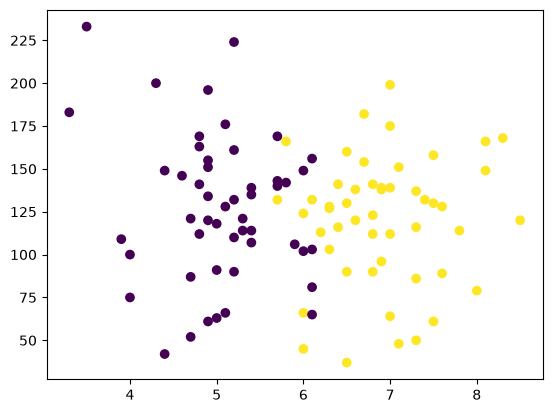

In [9]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [10]:
# df.dropna()

In [11]:
# train_data=df.iloc[:90,:]

In [12]:
# train_data.tail()

In [13]:
# test_data=df.iloc[90:,:]

In [14]:
# test_data.head()

In [15]:
x=df.iloc[:,:2]
y=df.iloc[:,-1]

In [16]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [17]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test =train_test_split(x,y,test_size=0.1)

In [19]:
x_train.head()

,cgpa,iq
36,5.7,140.0
69,8.5,120.0
30,7.6,128.0
49,5.4,135.0
37,8.1,149.0


In [20]:
y_train.head()

36    0
69    1
30    1
49    0
37    1
Name: placement, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
x_train = scaler.fit_transform(x_train)

In [24]:
x_train

array([[-2.50435478e-01,  4.10774748e-01],
       [ 2.28409225e+00, -1.05201907e-01],
       [ 1.46942262e+00,  1.01188755e-01],
       [-5.21992020e-01,  2.81780585e-01],
       [ 1.92201686e+00,  6.42964243e-01],
       [-7.03029715e-01, -3.63190235e-01],
       [-5.21992020e-01,  3.84975916e-01],
       [ 1.65046032e+00, -2.59994904e-01],
       [ 1.19786608e+00, -9.82362221e-01],
       [-8.84067410e-01, -8.53368057e-01],
       [ 2.10305456e+00,  1.13314207e+00],
       [ 5.64234149e-01,  3.59177083e-01],
       [-1.42718050e+00,  6.42964243e-01],
       [-1.15562395e+00, -9.56563388e-01],
       [ 7.45271844e-01, -8.79166890e-01],
       [ 9.26309539e-01, -3.11592569e-01],
       [-1.78925589e+00, -6.21178562e-01],
       [-9.74586258e-01,  6.94561909e-01],
       [ 4.73715302e-01, -8.79166890e-01],
       [ 1.92201686e+00,  1.08154440e+00],
       [ 1.11639912e-01, -5.43782064e-01],
       [-2.50435478e-01,  1.15894090e+00],
       [ 1.11639912e-01,  2.04384086e-01],
       [ 1.

In [25]:
x_test=scaler.transform(x_test)

In [26]:
x_test

array([[ 1.19786608, -0.20839724],
       [ 0.92630954,  1.93290588],
       [ 0.56423415, -0.10520191],
       [-1.78925589, -1.26614938],
       [-0.15991663,  0.46237241],
       [ 0.02112106, -2.04011436],
       [-2.42288782,  1.52012456],
       [ 1.83149801, -1.16295405],
       [ 1.01682839,  0.69456191],
       [ 0.11163991, -1.11135638]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf=LogisticRegression()

In [29]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [30]:
y_pred = clf.predict(x_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)*100

90.0

# *How to plot decision boundary*

## <b>use mlxtend plot decision boundary</b>

<Axes: >

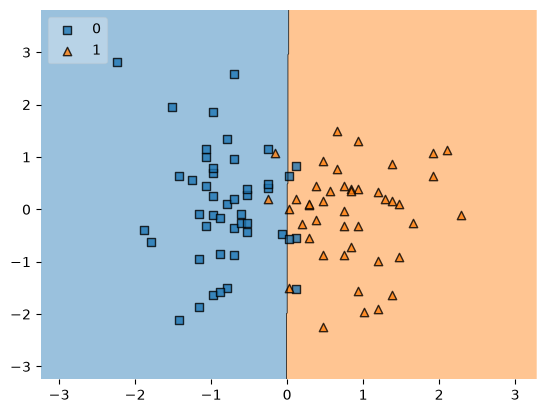

In [33]:
#Example 1 - Decision regions in 2D
from mlxtend.plotting import plot_decision_regions
 
# Plotting decision regions
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [35]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))